In [37]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
import statsmodels.formula.api as smf
import sklearn
import scipy 
from scipy.linalg import eigh, cholesky
from scipy.stats import norm
import linearmodels.panel as lmp
from pylab import plot, show, axis, subplot, xlabel, ylabel, grid
import semopy 
import seaborn as sns
from factor_analyzer import FactorAnalyzer
from sklearn.decomposition import PCA
from IPython.display import Image


%matplotlib inline

#### Pregunta 1: Cargue la base de datos y realice los ajustes necesarios para su uso (missing values, recodificar variables, etcetera). Identifique los tipos de datos que se encuentran en la base, realice estadisticas descriptivas sobre las variables importantes (Hint: Revisar la distribuciones, datos faltantes, outliers, etc.) y limpie las variables cuando sea necesario.
#### Primero es necesario caracterizar los datos y darles un poco de forma, aplicar algunas estadisticas descriptivas para entender la naturaleza de estos

               sexo          edad          imce    vive_padre    vive_madre  \
count  41854.000000  41854.000000  41854.000000  41854.000000  41854.000000   
mean       0.552325     83.066039      1.014083      0.720051      0.965141   
std        0.497261      3.987135      1.380418      0.449830      0.192328   
min        0.000000     62.000000     -5.020000      0.000000      0.000000   
25%        0.000000     81.000000      0.100000      0.000000      1.000000   
50%        1.000000     82.000000      0.970000      1.000000      1.000000   
75%        1.000000     84.000000      1.930000      1.000000      1.000000   
max        1.000000    107.000000      5.040000      2.000000      2.000000   

                sk1           sk2           sk3           sk4           sk5  \
count  41854.000000  41854.000000  41854.000000  41854.000000  41854.000000   
mean       1.117958      1.397310      1.270129      1.263129      1.275935   
std        0.401019      0.661753      0.594456    

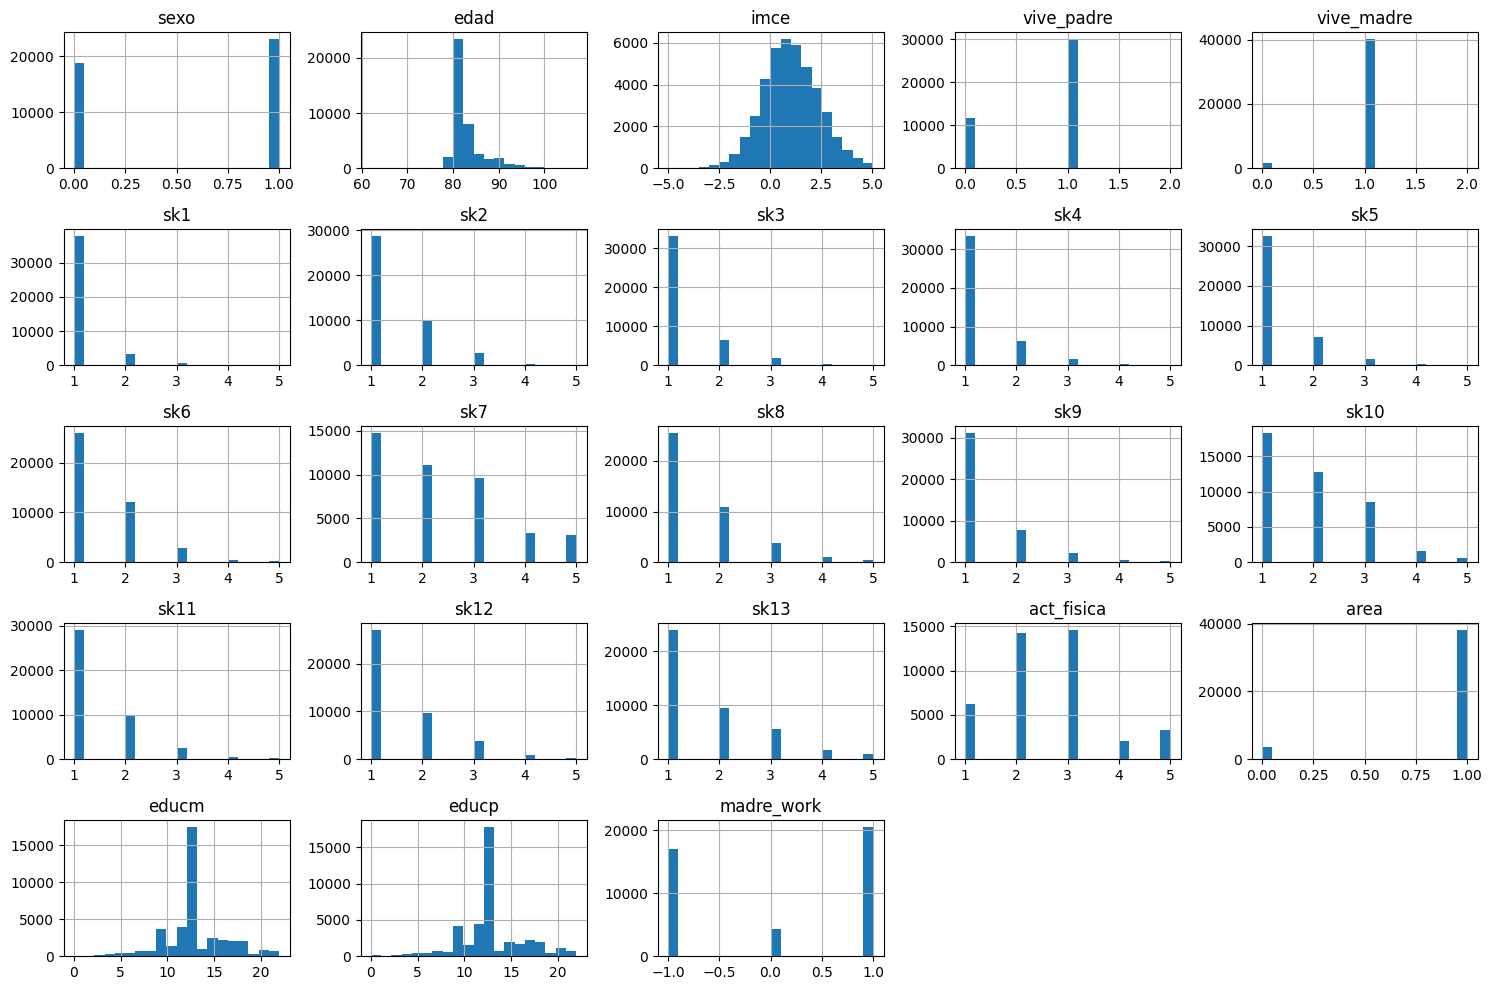

In [38]:
#lectura data
df=pd.read_csv('../data/junaeb2.csv')
df.describe()
# Estadísticas descriptivas
print(df.describe(include='all'))

# Histograma de todas las variables numéricas
df.hist(bins=20, figsize=(15, 10))
plt.tight_layout()
plt.show()



### analizar que valores estan presentes en cada parametro para serciorarse que sean valores dentro de los rangos permitidos

In [39]:
df.columns.values.tolist()
for i in df.columns:
    print({i}, df[i].unique())

{'sexo'} [1 0]
{'edad'} [ 85  76  68  84  86  74  91  92  69  80  78  79  73  82  83  75  77  71
 107 106 105 104 103 102 101 100  99  98  97  96  95  94  93  90  89  81
  88  65  87  62]
{'imce'} [ 0.75        0.70999998  0.27000001  2.05        1.05        1.39
  2.75        1.53        1.96        1.76        0.          0.04
  1.9299999   1.65        0.52999997  1.14        2.53        1.75
  0.43000001  1.29        0.67000002 -1.45        3.4100001   2.98
 -0.12        1.77        2.03        1.1         2.0799999   2.7
 -0.02       -0.11       -0.40000001  1.9         0.60000002  0.61000001
 -2.3699999   2.52        0.5         1.9400001   1.25        1.41
 -0.55000001  0.63999999  0.31       -0.09       -1.15        0.66000003
  0.05        0.94999999  0.69999999  0.97000003  2.21        1.78
  2.9200001  -0.30000001  0.49000001  0.44999999  1.5700001   2.04
  0.16       -1.52        2.1600001  -0.03        4.1599998   0.55000001
  1.62        3.22        0.40000001 -0.25       

### También transformamos las edades de meses a años, junto con esto, agregamos una columna de los meses que actualmente tienen antes de cumplir otro año, también se invierte el signo de sk7

In [40]:
df['edad'] = df['edad']/12  # Convertir edad a años
# Convertir edad de meses a años y meses
df['edad_años'] = df['edad'].astype(int)
df['edad_meses'] = ((df['edad'] - df['edad_años']) * 12).round().astype(int)

print(df[['edad', 'edad_años', 'edad_meses']])

df['sk7'] = 6 - df['sk7']

           edad  edad_años  edad_meses
0      7.083333          7           1
1      6.333333          6           4
2      5.666667          5           8
3      7.000000          7           0
4      7.166667          7           2
...         ...        ...         ...
41849  6.500000          6           6
41850  6.583333          6           7
41851  6.500000          6           6
41852  6.500000          6           6
41853  6.500000          6           6

[41854 rows x 3 columns]


In [41]:
df.dropna()

,sexo,edad,imce,vive_padre,vive_madre,sk1,sk2,sk3,sk4,sk5,...,sk11,sk12,sk13,act_fisica,area,educm,educp,madre_work,edad_años,edad_meses
1,0,6.333333,0.71,0,1,1,1,1,1,1,...,1,1,1,5.0,0,8.0,8,1,6,4
3,1,7.000000,2.05,1,1,1,1,1,1,1,...,1,1,1,2.0,1,16.0,12,-1,7,0
4,0,7.166667,1.05,1,1,1,1,1,1,1,...,1,1,1,1.0,1,17.0,15,0,7,2
5,0,6.166667,1.39,1,1,1,2,1,1,1,...,1,1,1,4.0,0,8.0,8,-1,6,2
6,1,7.583333,2.75,1,1,1,1,1,2,2,...,3,2,2,2.0,1,20.0,19,1,7,7
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41849,0,6.500000,1.63,1,1,1,3,1,2,2,...,2,1,1,2.0,1,13.0,13,-1,6,6
41850,1,6.583333,2.57,1,1,1,1,2,2,1,...,2,1,4,3.0,1,18.0,19,0,6,7
41851,0,6.500000,2.12,1,1,1,1,1,1,1,...,1,1,1,3.0,1,13.0,9,1,6,6
41852,1,6.500000,-0.43,1,1,1,1,1,1,2,...,1,1,2,2.0,1,17.0,15,1,6,6


#### Pregunta 2: Usando las variables sk1-sk13 realice un PCA. En particular, identifique los valores propios y determine el numero optimo de componentes. Luego estime y grafique la distribucion de los componentes. Ademas discuta la importancia relativa de las variables sobre cada uno de los componentes estimados. Que se puede concluir de este analisis?



Matriz de Varianza-Covarianza:
           sk1       sk2       sk3       sk4       sk5       sk6       sk7  \
sk1   0.160816  0.121890  0.084232  0.099418  0.055879  0.065479 -0.059660   
sk2   0.121890  0.437917  0.148950  0.163177  0.143776  0.167329 -0.100785   
sk3   0.084232  0.148950  0.353378  0.185030  0.098853  0.103283 -0.029640   
sk4   0.099418  0.163177  0.185030  0.346765  0.114236  0.119261 -0.052037   
sk5   0.055879  0.143776  0.098853  0.114236  0.331021  0.181345 -0.059160   
sk6   0.065479  0.167329  0.103283  0.119261  0.181345  0.557886 -0.171452   
sk7  -0.059660 -0.100785 -0.029640 -0.052037 -0.059160 -0.171452  1.501665   
sk8   0.056942  0.150658  0.102061  0.112041  0.206584  0.169575 -0.066551   
sk9   0.066859  0.107903  0.115756  0.123011  0.101556  0.120640 -0.068758   
sk10  0.076710  0.145020  0.105093  0.118927  0.099153  0.150613 -0.103642   
sk11  0.075931  0.136644  0.117805  0.127016  0.109500  0.134608 -0.088950   
sk12  0.060579  0.107231  0.09771

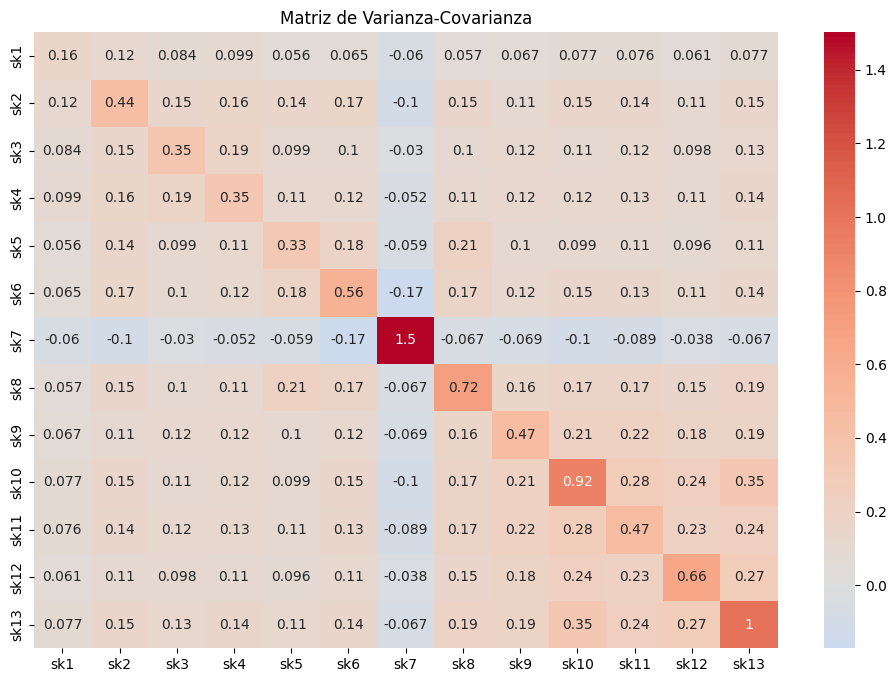

In [ ]:
#Para las variables originales (sk1-sk13) calculamos la matriz de varianza-covarianza
sk_vars = ['sk1', 'sk2', 'sk3', 'sk4', 'sk5', 'sk6', 'sk7', 'sk8', 'sk9', 'sk10', 'sk11', 'sk12', 'sk13']
cov_matrix = df[sk_vars].cov()
var_matrix = df[sk_vars].var()


print("Matriz de Varianza-Covarianza:")
print(cov_matrix)

plt.figure(figsize=(12, 8))
sns.heatmap(cov_matrix, annot=True, cmap='coolwarm', center=0)
plt.title('Matriz de Varianza-Covarianza')
plt.show()

In [52]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
sk_data_std = pd.DataFrame(scaler.fit_transform(df[sk_vars]), columns=sk_vars)

pca = PCA()
pca_result = pca.fit_transform(sk_data_std)
dfpca1= pd.DataFrame(pca_result, columns=[f'PC{i+1}' for i in range(pca_result.shape[1])])
print(pca_result)

[[ 0.99173088  1.37116719  0.58758255 ...  0.19602155  0.13949011
   1.23485196]
 [-1.83422399 -0.572447   -0.50026172 ...  0.27280703  0.07133031
  -0.05159715]
 [ 3.43462297 -0.99003682  1.65765512 ... -0.98535343  0.35421771
  -1.0469    ]
 ...
 [-1.52511168  0.48590559  0.65987299 ...  0.31093164 -0.32274882
  -0.06124731]
 [-0.36621802 -0.12287925 -0.97598573 ...  0.61291871  0.110111
  -0.32231078]
 [-0.57980857 -1.85479421 -0.0973969  ...  0.23239956 -0.0200325
  -0.45371988]]


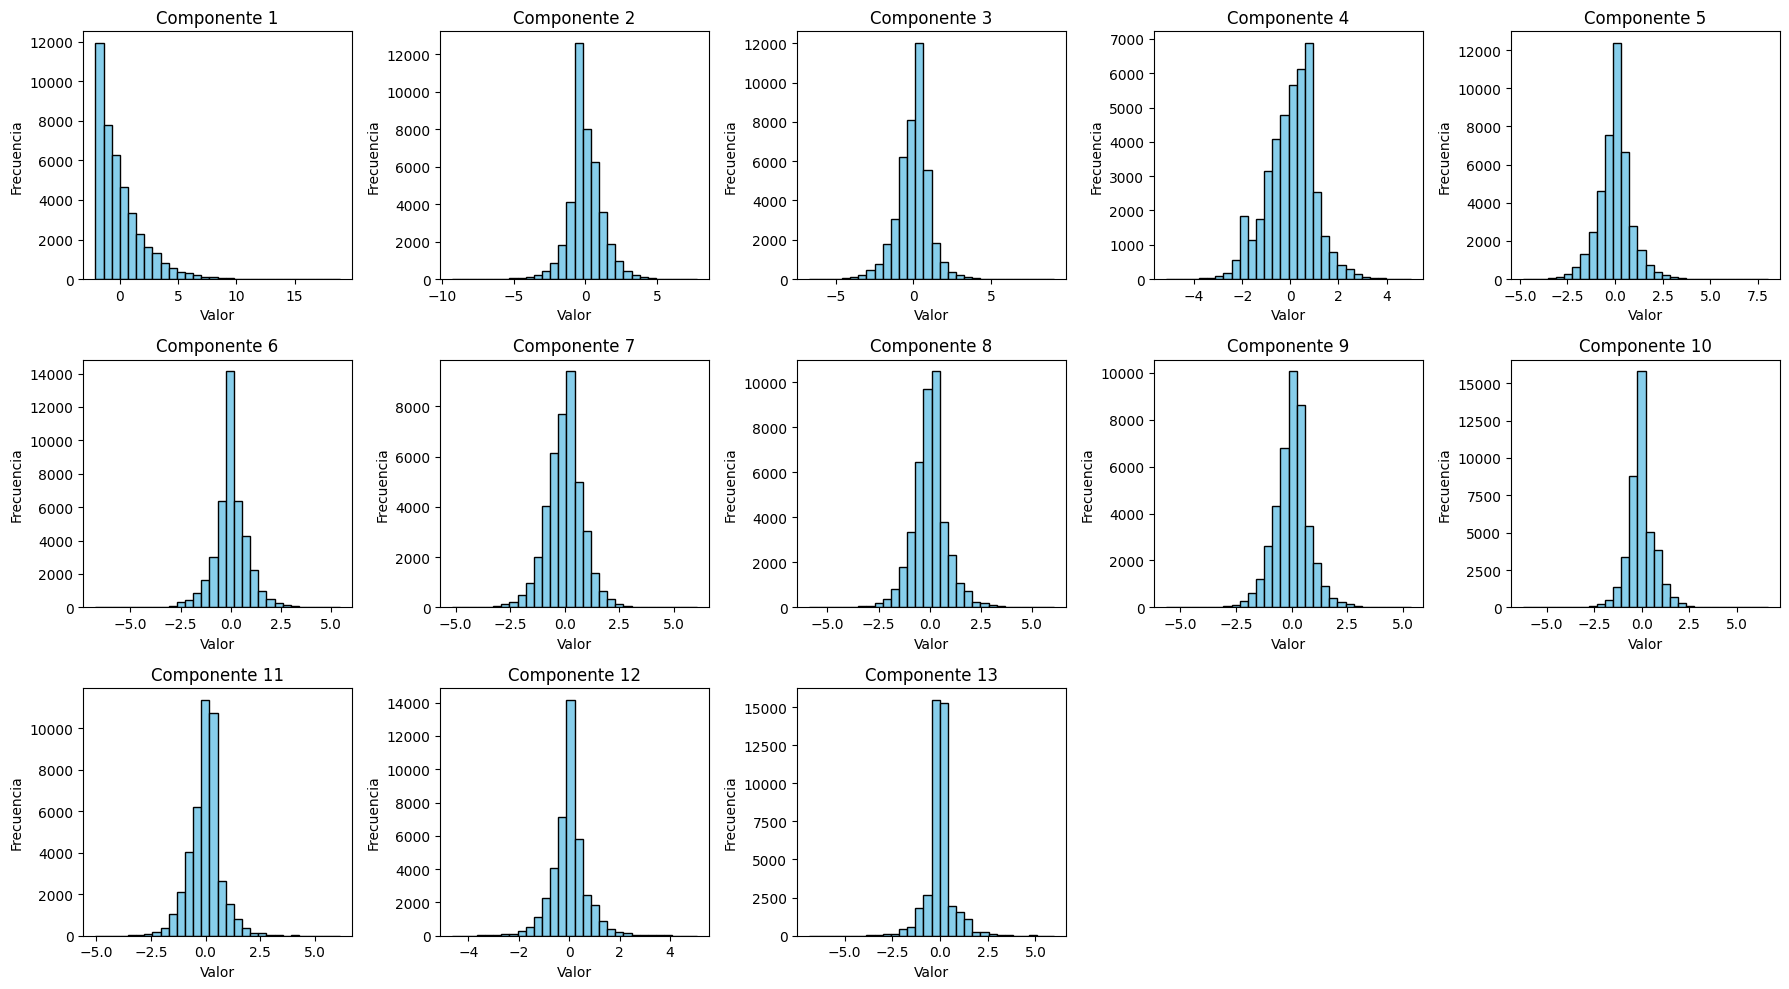

In [ ]:
plt.figure(figsize=(18, 10))
for i in range(pca_result.shape[1]):
    plt.subplot(3, 5, i+1)
    plt.hist(pca_result[:, i], bins=30, color='skyblue', edgecolor='black')
    plt.title(f'Componente {i+1}')
    plt.xlabel('Valor')
    plt.ylabel('Frecuencia')
plt.tight_layout()
plt.show()

Valores propios:
[4.15436549 1.3365652  1.09910896 0.99951711 0.77210514 0.70114337
 0.69214386 0.68409742 0.59662788 0.5155363  0.50584496 0.4874235
 0.45583142]

Varianza explicada acumulada:
[0.31955894 0.42236919 0.50691402 0.58379811 0.64318939 0.69712221
 0.75036277 0.8029844  0.84887775 0.88853344 0.92744366 0.96493688
 1.        ]


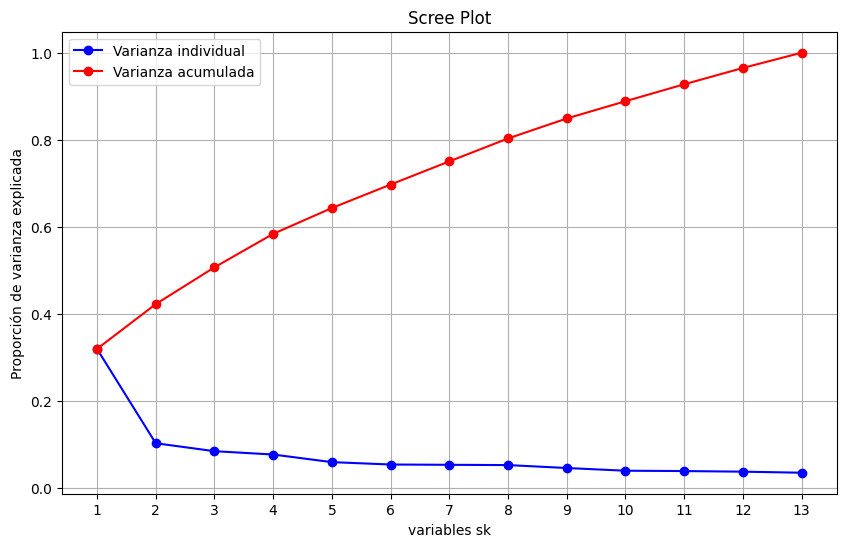

In [45]:
# Calcular y mostrar los valores propios
print("Valores propios:")
print(pca.explained_variance_)

# Varianza explicada acumulada
var_acum = np.cumsum(pca.explained_variance_ratio_)
print("\nVarianza explicada acumulada:")
print(var_acum)

# Scree plot
plt.figure(figsize=(10, 6))
plt.xticks(ticks=range(1, 14), labels=range(1, 14))
plt.plot(range(1, 14), pca.explained_variance_ratio_, 'bo-')
plt.plot(range(1, 14), var_acum, 'ro-')
plt.xlabel('variables sk')
plt.ylabel('Proporción de varianza explicada')
plt.title('Scree Plot')
plt.legend(['Varianza individual', 'Varianza acumulada'])
plt.grid(True)
plt.show()

#### En vista de que los primeros 3 componentes tienen valores propios significativos, realizamos PCA con 3 componentes


Cargas de las variables en cada componente:
           PC1       PC2       PC3
sk1   0.279653 -0.292463  0.279524
sk2   0.316201 -0.313067  0.047264
sk3   0.293847 -0.275114  0.352083
sk4   0.320114 -0.290624  0.303434
sk5   0.294515 -0.208955 -0.372546
sk6   0.267577 -0.164967 -0.443692
sk7  -0.097080  0.097966  0.448011
sk8   0.259011  0.026300 -0.385174
sk9   0.296544  0.231483  0.042543
sk10  0.262194  0.392498  0.030369
sk11  0.330260  0.307261  0.042749
sk12  0.257829  0.384105  0.075601
sk13  0.256734  0.354336  0.092720


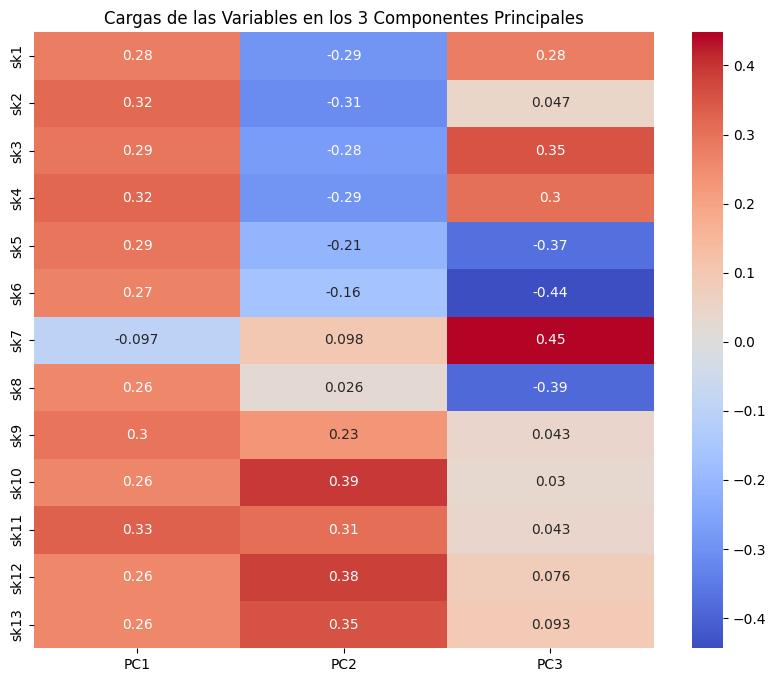

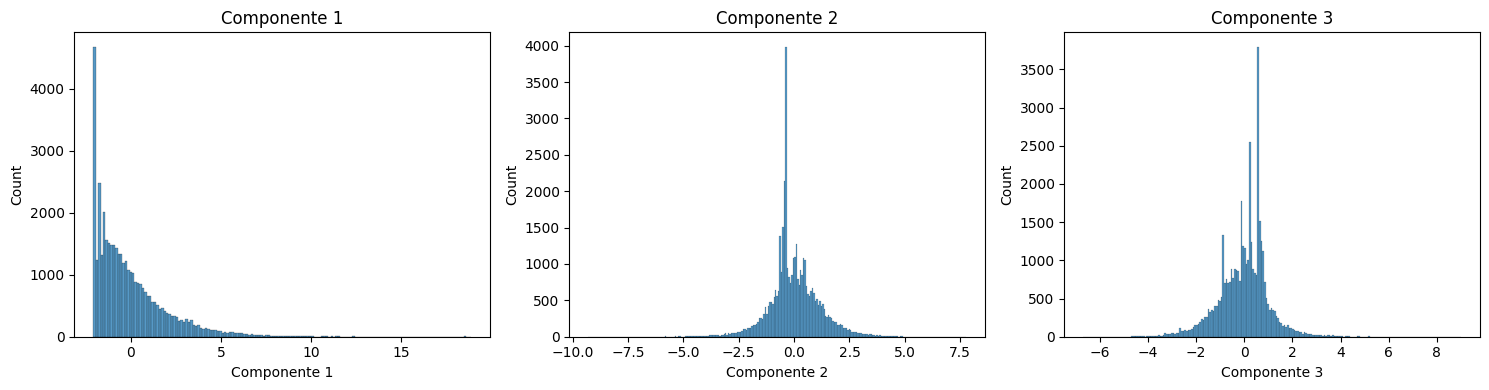

In [ ]:
pca3 = PCA(n_components=3)
pca_result_3 = pca3.fit_transform(sk_data_std)

pca_df_3 = pd.DataFrame(
    pca_result_3, 
    columns=['Componente 1', 'Componente 2', 'Componente 3']
)

loadings_3 = pd.DataFrame(
    pca3.components_.T,
    columns=['PC1', 'PC2', 'PC3'],
    index=sk_vars
)

print("Cargas de las variables en cada componente:")
print(loadings_3)

plt.figure(figsize=(10, 8))
sns.heatmap(loadings_3, annot=True, cmap='coolwarm', center=0)
plt.title('Cargas de las Variables en los 3 Componentes Principales')
plt.show()

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for i, ax in enumerate(axes):
    sns.histplot(data=pca_df_3[f'Componente {i+1}'], ax=ax)
    ax.set_title(f'Componente {i+1}')
plt.tight_layout()
plt.show()

#### 3. Con los resultados de la Pregunta 2, mantenga los primeros 3 componentes principales. Graficamente indique si existen diferencias significativas entre grupos usando las siguientes variables: sexo, area, madre_work y act_fisica. Que puede concluir de los resultados?

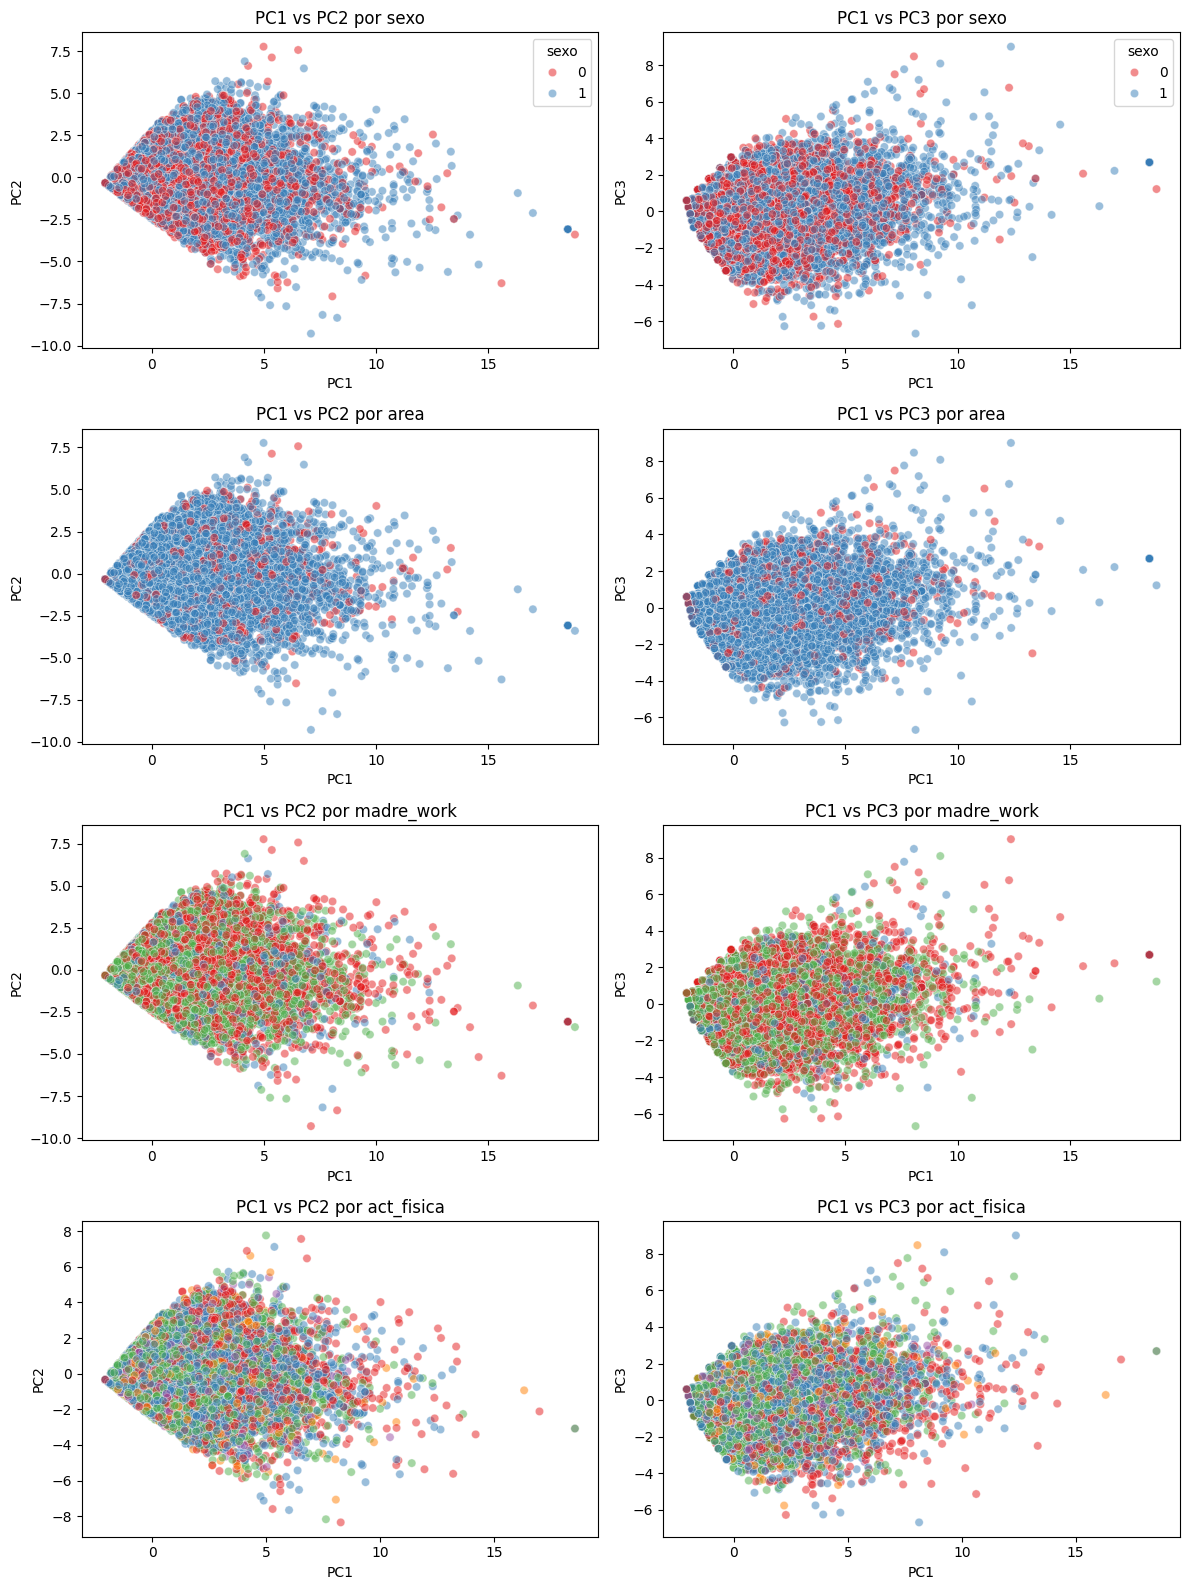

In [ ]:
# Variables categóricas a analizar
categorical_vars = ['sexo', 'area', 'madre_work', 'act_fisica']

df_plot_pca3 = pd.concat([pca_df_3, df[categorical_vars].reset_index(drop=True)], axis=1)
df_plot_pca3.columns = ['PC1', 'PC2', 'PC3'] + categorical_vars

fig, axes = plt.subplots(len(categorical_vars), 2, figsize=(12, 16))
for i, var in enumerate(categorical_vars):
    # PCA 3 componentes principales
    sns.scatterplot(
        data=df_plot_pca3, x='PC1', y='PC2', hue=var, palette='Set1', alpha=0.5, ax=axes[i, 0], legend='full' if i == 0 else False
    )
    axes[i, 0].set_title(f'PC1 vs PC2 por {var}')
    axes[i, 0].set_xlabel('PC1')
    axes[i, 0].set_ylabel('PC2')
    # PC1 vs PC3
    sns.scatterplot(
        data=df_plot_pca3, x='PC1', y='PC3', hue=var, palette='Set1', alpha=0.5, ax=axes[i, 1], legend='full' if i == 0 else False
    )
    axes[i, 1].set_title(f'PC1 vs PC3 por {var}')
    axes[i, 1].set_xlabel('PC1')
    axes[i, 1].set_ylabel('PC3')
plt.tight_layout()
plt.show()

#### 4. A partir del mismo set de variables sk1-sk13 realice un EFA. En particular determine el numero optimo de factores y las variables que se asocian a cada factor. Tambien discuta si existen variables que no son informativas (Hint: para realizar un EFA, todas las variables deben estar representatadas en el mismo sentido logico. Si una carateristica es negativa debe ser invertida en la escala, de tal forma que todas las variables representen aspectos positivos).


In [60]:
data_sk=df[['sk1','sk2','sk3','sk4','sk5','sk6','sk8','sk9','sk10','sk11','sk12','sk13']]
fa = FactorAnalyzer(rotation='oblimin', n_factors=3).fit(data_sk);
np.set_printoptions(suppress=True, formatter={'float_kind':'{:f}'.format})
fa.loadings_

d:\VSCODE ENVIROMENTS\proyectos universidad\data analysis y ML\LAB-MAA\notebooks\.venv\Lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


array([[0.023972, 0.612775, -0.039271],
       [0.007854, 0.524294, 0.187951],
       [0.016791, 0.651873, -0.021858],
       [-0.001211, 0.736657, -0.008124],
       [-0.028339, 0.017251, 0.823906],
       [0.105271, 0.103327, 0.409711],
       [0.236554, -0.064221, 0.441652],
       [0.505329, 0.087732, 0.050570],
       [0.619386, -0.033095, -0.030541],
       [0.697787, 0.038263, 0.008667],
       [0.577668, -0.032837, 0.005541],
       [0.537320, 0.015562, -0.012449]])

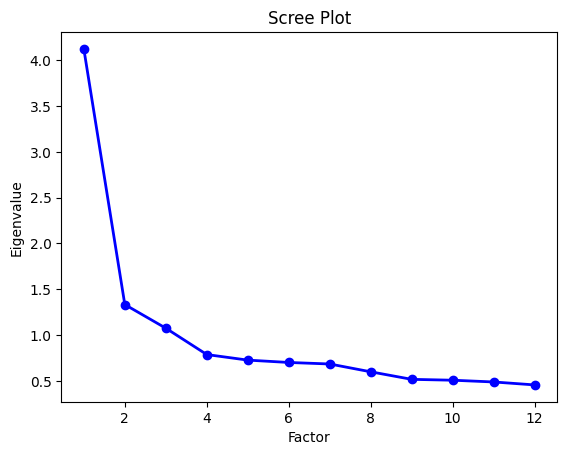

In [ ]:

values = np.arange(1,13)
eigenvalues = pd.DataFrame(data=fa.get_eigenvalues());
plt.plot(values, eigenvalues.loc[0], 'o-', linewidth=2, color='blue');
plt.title('Scree Plot')
plt.xlabel('Factor')
plt.ylabel('Eigenvalue')
plt.show()



#### utilizando el criterio kaiser (eigenvalues > 1), se entiende que el numero optimo de factores es 3.


#### 5. Con los resultados obtenidos en la Pregunta 4, proponga un CFA donde cada variable solo se asocia con un factor. Entregue un nombre a cada factor que representa el concepto comun entre todas las variables. Reporte la importancia de cada medida (variable) a cada factor e indique la correlacion entre factores.


In [ ]:
from factor_analyzer import (ConfirmatoryFactorAnalyzer, ModelSpecificationParser)
model_dict = {"F2": ["sk1", "sk2", "sk3", "sk4"], #habilidades socioemocionales
              "F1": ["sk5", "sk6", "sk8"], #habilidades relacionales
              "F3": ["sk9", "sk10", "sk11", "sk12", "sk13"]} ##habilidades cognitivas
model_spec = ModelSpecificationParser.parse_model_specification_from_dict(data_sk, model_dict)
cfa = ConfirmatoryFactorAnalyzer(model_spec, disp=False).fit(data_sk)
cfa.factor_varcovs_

d:\VSCODE ENVIROMENTS\proyectos universidad\data analysis y ML\LAB-MAA\notebooks\.venv\Lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
d:\VSCODE ENVIROMENTS\proyectos universidad\data analysis y ML\LAB-MAA\notebooks\.venv\Lib\site-packages\factor_analyzer\confirmatory_factor_analyzer.py:753: UserWarning: The optimization routine failed to converge: ABNORMAL: 
  warnings.warn(


array([[1.000000, 0.139775, 0.145129],
       [0.139775, 1.000000, 0.156513],
       [0.145129, 0.156513, 1.000000]])

In [65]:
loadings = pd.DataFrame(fa.loadings_, index=data_sk.columns, columns=['Factor1', 'Factor2', 'Factor3'])
print(loadings)
print("\nVariables asociadas a cada factor (carga > 0.3):")
for factor in loadings.columns:
    asociadas = loadings.index[loadings[factor].abs() > 0.3].tolist()
    print(f"{factor}: {asociadas}")

       Factor1   Factor2   Factor3
sk1   0.023972  0.612775 -0.039271
sk2   0.007854  0.524294  0.187951
sk3   0.016791  0.651873 -0.021858
sk4  -0.001211  0.736657 -0.008124
sk5  -0.028339  0.017251  0.823906
sk6   0.105271  0.103327  0.409711
sk8   0.236554 -0.064221  0.441652
sk9   0.505329  0.087732  0.050570
sk10  0.619386 -0.033095 -0.030541
sk11  0.697787  0.038263  0.008667
sk12  0.577668 -0.032837  0.005541
sk13  0.537320  0.015562 -0.012449

Variables asociadas a cada factor (carga > 0.3):
Factor1: ['sk9', 'sk10', 'sk11', 'sk12', 'sk13']
Factor2: ['sk1', 'sk2', 'sk3', 'sk4']
Factor3: ['sk5', 'sk6', 'sk8']


#### 6. Finalmente, implemente un SEM completo usando la estructura propuesta en la Pregunta 5. En particular, estime un modelo donde los factores explican el nivel de actividad fisica, junto con otras variables que existen en la base de datos. Ademas utilice otras variables relevantes de la base de datos para explicar los factores latentes. Las variables a incluir en el modelo final deben tener sustento teorico y el modelo final debe optimizar el ajuste a los datos, en base a los criterios vistos en clase. Que puede concluir en base a sus resultados?


In [82]:
mod = '''
#measurement
F1 =~ sk5 + sk6 + sk8 #habilidades relacionales
F2 =~ sk1 + sk2 + sk3 + sk4 #habilidades socioemocionales
F3 =~ sk9 + sk10 + sk11 + sk12 + sk13 #habilidades cognitivas

# Factores explicados por variables externas
F1 ~ sexo + edad
F2 ~ vive_padre + vive_madre
F3 ~ educm + educp


# act_fisica explicada por los factores
act_fisica ~ F1 + F2 + F3
'''
#el sexo y la edad son variables exógenas que explican las habilidades relacionales (F1)
#dado que los contextos asociados a las etapas de la vida influyen altamente en estos aspectos y se 
#diferencian entre hombres y mujeres.

#para F2, las habilidades socioemocionales, se incluyen las variables vive_padre y vive_madre
#esto se interpreta de el hecho de que la presencia de los padres en el hogar puede influir
#en el desarrollo de habilidades socioemocionales de las personas

#para las habilidades cognitivas (F3), se consideran las variables educm (educación de la madre)
# y educp (educación del padre), ya que la educación de los padres puede influir en el desarrollo
#cognitivo de los hijos, y se espera que estas variables tengan un efecto positivo en las habilidades cognitivas.


data_sem = df[['sk1','sk2','sk3','sk4','sk5','sk6','sk8','sk9','sk10','sk11','sk12','sk13',
               'act_fisica','sexo','edad','vive_padre', 'vive_madre','educm', 'educp']].dropna()
model = semopy.Model(mod)
out = model.fit(data_sem)
print(out)
stats = semopy.calc_stats(model)
print(stats)
results = model.inspect()
print(results)

Name of objective: MLW
Optimization method: SLSQP
Optimization successful.
Optimization terminated successfully
Objective value: 0.827
Number of iterations: 39
Params: 0.853 0.996 1.749 1.663 1.841 1.417 1.265 1.132 1.334 0.033 0.157 -0.017 -0.043 -0.015 -0.008 -0.341 0.087 -0.250 0.199 0.052 0.146 1.105 0.097 0.599 0.213 0.447 0.723 0.268 0.197 0.158 0.121 0.400 0.502 0.297
       DoF  DoF Baseline          chi2  chi2 p-value  chi2 Baseline       CFI  \
Value  156           177  32998.365517           0.0  139186.017356  0.763739   

            GFI      AGFI       NFI       TLI     RMSEA        AIC  \
Value  0.762919  0.731004  0.762919  0.731935  0.072641  66.345864   

              BIC    LogLik  
Value  358.544634  0.827068  
          lval  op        rval  Estimate  Std. Err     z-value   p-value
0           F1   ~        sexo  0.032689  0.005357    6.101556       0.0
1           F1   ~        edad  0.157112  0.008146   19.286782       0.0
2           F2   ~  vive_padre -0.01719

#### 7. Repita el analisis de la Pregunta 6 usando para cada submuestra generada a partir de las clases latentes obtenida en la pregunta 5. Reporte diferencias entre los parametros entre los distintos grupos (si existieran). Hay alguna ganancia de estimar el modelo por grupos versus el modelo general?